In [38]:
# ============================================================
# CELL 1: Install Dependencies + Import Libraries
# ============================================================
import subprocess
import sys

def install_if_missing(package, import_name=None):
    import_name = import_name or package
    try:
        __import__(import_name)
        print(f"[OK] {package} sudah ter-install")
    except ImportError:
        print(f"[INSTALL] Installing {package}...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", package])
        print(f"[OK] {package} berhasil di-install")

install_if_missing("PyWavelets", "pywt")
install_if_missing("scipy")
install_if_missing("scikit-learn", "sklearn")
install_if_missing("tensorflow")
install_if_missing("Pillow", "PIL")

import os
import gc
import json
import shutil
import zipfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pywt
from pathlib import Path
from collections import Counter
from datetime import datetime

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications import EfficientNetV2B0
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

from sklearn.utils.class_weight import compute_class_weight

gc.collect()

print("=" * 60)
print(f"TensorFlow version: {tf.__version__}")
print(f"GPU available: {len(tf.config.list_physical_devices('GPU')) > 0}")
print("=" * 60)

[OK] PyWavelets sudah ter-install
[OK] scipy sudah ter-install
[OK] scikit-learn sudah ter-install
[OK] tensorflow sudah ter-install
[OK] Pillow sudah ter-install
TensorFlow version: 2.20.0
GPU available: False


In [39]:
# ============================================================
# CELL 2: Mount Drive, Copy ZIP, dan Unzip Dataset
# ============================================================
print("=" * 60)
print("DATA PREPARATION: MOUNT DRIVE → COPY → UNZIP")
print("=" * 60)

# --- Konfigurasi Path ---
DRIVE_MOUNT_POINT = "/content/drive"
ZIP_SOURCE_PATH = Path("/content/drive/MyDrive/dataset_echonet/echonext.zip")
LOCAL_ZIP_PATH = Path("/content/echonext.zip")
EXTRACT_DIR = Path("/content/echonext")

# --- Step 1: Mount Google Drive ---
print("\n[Step 1/3] Mounting Google Drive...")
from google.colab import drive

if os.path.exists(DRIVE_MOUNT_POINT + "/MyDrive"):
    print("[OK] Google Drive sudah ter-mount")
else:
    print("[INFO] Mounting Google Drive...")
    drive.mount(DRIVE_MOUNT_POINT)
    print("[OK] Google Drive berhasil di-mount")

# --- Step 2: Copy ZIP ---
print("\n[Step 2/3] Copy ZIP dari Drive ke disk lokal...")
if not ZIP_SOURCE_PATH.exists():
    print(f"[ERROR] File tidak ditemukan: {ZIP_SOURCE_PATH}")
    drive_folder = Path("/content/drive/MyDrive/dataset_echonet")
    if drive_folder.exists():
        print("[DEBUG] Isi folder:")
        for item in sorted(drive_folder.iterdir()):
            print(f"  - {item.name}")
else:
    if LOCAL_ZIP_PATH.exists():
        print(f"[OK] ZIP sudah ada di disk lokal: {LOCAL_ZIP_PATH}")
    else:
        print(f"[INFO] Copying {ZIP_SOURCE_PATH.name} (6+ GB, ini akan memakan waktu)...")
        start_time = datetime.now()
        shutil.copy2(ZIP_SOURCE_PATH, LOCAL_ZIP_PATH)
        elapsed = (datetime.now() - start_time).total_seconds()
        size_mb = LOCAL_ZIP_PATH.stat().st_size / (1024 * 1024)
        print(f"[OK] Copy selesai dalam {elapsed:.1f} detik")
        print(f"     Ukuran: {size_mb:.2f} MB")

# --- Step 3: Unzip ---
print("\n[Step 3/3] Unzipping dataset (22+ GB setelah extract)...")
if EXTRACT_DIR.exists() and any(EXTRACT_DIR.iterdir()):
    print(f"[OK] Dataset sudah di-extract: {EXTRACT_DIR}")
else:
    print(f"[INFO] Extracting ke {EXTRACT_DIR}...")
    print("       (Ini akan memakan waktu beberapa menit)")
    EXTRACT_DIR.mkdir(parents=True, exist_ok=True)
    start_time = datetime.now()

    with zipfile.ZipFile(LOCAL_ZIP_PATH, 'r') as zf:
        zf.extractall(EXTRACT_DIR)

    elapsed = (datetime.now() - start_time).total_seconds()
    print(f"[OK] Unzip selesai dalam {elapsed:.1f} detik")

# --- Verifikasi ---
print("\n[VERIFIKASI]")
if EXTRACT_DIR.exists():
    subdirs = [d for d in EXTRACT_DIR.iterdir() if d.is_dir()]
    print(f"  Subdirectories: {len(subdirs)}")

    # Cari folder dataset
    dataset_root = None
    for d in subdirs:
        if "echonext" in d.name.lower():
            dataset_root = d
            break

    if dataset_root:
        print(f"  Dataset root: {dataset_root}")
        npy_files = list(dataset_root.glob("*.npy"))
        print(f"  NPY files: {len(npy_files)}")
        for npy in npy_files[:4]:
            size_mb = npy.stat().st_size / (1024 * 1024)
            print(f"    - {npy.name} ({size_mb:.1f} MB)")

print("\n" + "=" * 60)
print("DATA PREPARATION SELESAI!")
print("=" * 60)

DATA PREPARATION: MOUNT DRIVE → COPY → UNZIP

[Step 1/3] Mounting Google Drive...
[OK] Google Drive sudah ter-mount

[Step 2/3] Copy ZIP dari Drive ke disk lokal...
[OK] ZIP sudah ada di disk lokal: /content/echonext.zip

[Step 3/3] Unzipping dataset (22+ GB setelah extract)...
[OK] Dataset sudah di-extract: /content/echonext

[VERIFIKASI]
  Subdirectories: 1
  Dataset root: /content/echonext/echonext-a-dataset-for-detecting-echocardiogram-confirmed-structural-heart-disease-from-ecgs-1.1.0
  NPY files: 8
    - EchoNext_train_waveforms.npy (16588.2 MB)
    - EchoNext_val_tabular_features.npy (0.2 MB)
    - EchoNext_test_waveforms.npy (1245.6 MB)
    - EchoNext_val_waveforms.npy (1058.8 MB)

DATA PREPARATION SELESAI!


In [40]:
# ============================================================
# CELL 3: Konfigurasi Paths & Hyperparameters (UPDATED)
# ============================================================
print("=" * 60)
print("KONFIGURASI TRAINING - ECHONEXT (UPDATED)")
print("=" * 60)

# --- Auto-detect paths ---
EXTRACT_DIR = Path("/content/echonext")
dataset_root = None

for d in EXTRACT_DIR.iterdir():
    if d.is_dir() and "echonext" in d.name.lower():
        dataset_root = d
        break

if dataset_root is None:
    dataset_root = next(EXTRACT_DIR.iterdir())

ECHONEXT_DIR = dataset_root
METADATA_CSV = ECHONEXT_DIR / "echonext_metadata_100k.csv"

WAVEFORM_FILES = {
    "train": ECHONEXT_DIR / "EchoNext_train_waveforms.npy",
    "val": ECHONEXT_DIR / "EchoNext_val_waveforms.npy",
    "test": ECHONEXT_DIR / "EchoNext_test_waveforms.npy",
}

CONFIG = {
    # Data
    "max_samples_per_class": 1200,   # 600 HFrEF + 600 HFpEF
    "lvef_threshold_hfref": 40,
    "lvef_threshold_hfpef": 50,

    # ECG leads
    "selected_leads": [0, 1, 4],

    # CWT
    "wavelet": "morl",
    "scales": np.arange(1, 49),     # lebih ringan daripada 1-64
    "downsample_signal": 2,          # 2500 -> 1250, lebih hemat compute
    "cwt_output_size": 160,          # lebih ringan daripada 224

    # Training
    "batch_size": 16,
    "epochs": 60,
    "learning_rate": 1e-3,

    # Model
    "input_shape": (160, 160, 3),
    "dropout_rate": 0.30,

    # Cache
    "cache_dir": Path("/content/.echonext_cache"),
}

CONFIG["cache_dir"].mkdir(parents=True, exist_ok=True)

print(f"Dataset root: {ECHONEXT_DIR}")
print(f"Metadata CSV exists: {METADATA_CSV.exists()}")
print(f"Train waveforms exists: {WAVEFORM_FILES['train'].exists()}")

for key, value in CONFIG.items():
    if key not in ["scales", "cache_dir"]:
        print(f"  {key:25s}: {value}")

print("=" * 60)

KONFIGURASI TRAINING - ECHONEXT (UPDATED)
Dataset root: /content/echonext/echonext-a-dataset-for-detecting-echocardiogram-confirmed-structural-heart-disease-from-ecgs-1.1.0
Metadata CSV exists: True
Train waveforms exists: True
  max_samples_per_class    : 1200
  lvef_threshold_hfref     : 40
  lvef_threshold_hfpef     : 50
  selected_leads           : [0, 1, 4]
  wavelet                  : morl
  downsample_signal        : 2
  cwt_output_size          : 160
  batch_size               : 16
  epochs                   : 60
  learning_rate            : 0.001
  input_shape              : (160, 160, 3)
  dropout_rate             : 0.3


In [41]:
# ============================================================
# CELL 4: Load Metadata & Define Labels (FIXED)
# ============================================================
print("=" * 60)
print("LABEL DEFINITION: HFpEF vs HFrEF (FIXED)")
print("=" * 60)

# Ambil jumlah data train sebenarnya
_tmp_train = np.load(WAVEFORM_FILES["train"], mmap_mode="r")
MAX_TRAIN_IDX = _tmp_train.shape[0]
del _tmp_train
gc.collect()

print(f"Max train waveform index: {MAX_TRAIN_IDX}")

print("Loading metadata (chunked)...")
chunk_size = 10000
chunks = []

for chunk in pd.read_csv(METADATA_CSV, chunksize=chunk_size):
    relevant_cols = [
        "ecg_key",
        "patient_key",
        "age_at_ecg",
        "sex",
        "lvef_value",
        "lvef_lte_45_flag",
    ]
    available_cols = [c for c in relevant_cols if c in chunk.columns]
    chunks.append(chunk[available_cols])

df_meta = pd.concat(chunks, ignore_index=True)
del chunks
gc.collect()

print(f"Total records metadata: {len(df_meta)}")

# ============================================================
# ASUMSI PENTING:
# Baris 0 sampai MAX_TRAIN_IDX-1 di metadata sesuai dengan
# index waveform train.
#
# Jika dataset punya kolom split resmi, lebih baik pakai itu.
# Tapi dari notebook kamu, cara ini yang paling kompatibel.
# ============================================================
df_meta = df_meta.iloc[:MAX_TRAIN_IDX].copy()

print(f"Metadata train yang dipakai: {len(df_meta)}")

df_with_lvef = df_meta[df_meta["lvef_value"].notna()].copy()
print(f"With LVEF: {len(df_with_lvef)}")

def label_from_lvef(lvef):
    if lvef <= CONFIG["lvef_threshold_hfref"]:
        return 0  # HFrEF
    elif lvef >= CONFIG["lvef_threshold_hfpef"]:
        return 1  # HFpEF
    else:
        return None

df_with_lvef["label"] = df_with_lvef["lvef_value"].apply(label_from_lvef)

df_labeled = df_with_lvef[df_with_lvef["label"].notna()].copy()
df_labeled["label"] = df_labeled["label"].astype(int)

print("\nLabel distribution before subset:")
label_counts = df_labeled["label"].value_counts()

for label, count in label_counts.items():
    pct = count / len(df_labeled) * 100
    label_name = "HFrEF" if label == 0 else "HFpEF"
    print(f"  {label_name}: {count} ({pct:.1f}%)")

# ============================================================
# Balanced subset
# ============================================================
n_per_class = min(
    CONFIG["max_samples_per_class"],
    label_counts.min()
)

df_subset = (
    df_labeled
    .groupby("label", group_keys=False)
    .apply(lambda g: g.sample(n=n_per_class, random_state=42))
    .sample(frac=1, random_state=42)
)

print(f"\nSubset size: {len(df_subset)}")
print("Label distribution in subset:")
print(df_subset["label"].value_counts())

# Index df_subset harus tetap dipakai sebagai index waveform.
# Jangan reset_index di sini.

del df_meta, df_with_lvef, df_labeled
gc.collect()

print("=" * 60)

LABEL DEFINITION: HFpEF vs HFrEF (FIXED)
Max train waveform index: 72475
Loading metadata (chunked)...
Total records metadata: 100000
Metadata train yang dipakai: 72475
With LVEF: 66018

Label distribution before subset:
  HFpEF: 46949 (76.8%)
  HFrEF: 14200 (23.2%)

Subset size: 2400
Label distribution in subset:
label
1    1200
0    1200
Name: count, dtype: int64


/tmp/ipykernel_1105/3530316021.py:85: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g.sample(n=n_per_class, random_state=42))


In [42]:
# ============================================================
# CELL 5: Load Waveforms dengan Memory Mapping
# ============================================================
print("=" * 60)
print("LOAD WAVEFORMS (MEMORY MAPPING)")
print("=" * 60)

print("Loading train waveforms dengan mmap_mode='r'...")
waveforms_train_mmap = np.load(WAVEFORM_FILES["train"], mmap_mode="r")
print(f"  Shape: {waveforms_train_mmap.shape}")
print(f"  Dtype: {waveforms_train_mmap.dtype}")

print("\nLoading val waveforms...")
waveforms_val_mmap = np.load(WAVEFORM_FILES["val"], mmap_mode="r")
print(f"  Shape: {waveforms_val_mmap.shape}")

try:
    import psutil
    ram_used = psutil.Process(os.getpid()).memory_info().rss / (1024**2)
    print(f"\nRAM usage setelah mmap: {ram_used:.1f} MB")
except:
    print("\n(psutil tidak tersedia untuk cek RAM)")

print(f"\n✓ Waveforms loaded via memory mapping (RAM-friendly)")

gc.collect()

print("=" * 60)

LOAD WAVEFORMS (MEMORY MAPPING)
Loading train waveforms dengan mmap_mode='r'...
  Shape: (72475, 1, 2500, 12)
  Dtype: float64

Loading val waveforms...
  Shape: (4626, 1, 2500, 12)

RAM usage setelah mmap: 5301.2 MB

✓ Waveforms loaded via memory mapping (RAM-friendly)


In [43]:
# ============================================================
# CELL 6: CWT Preprocessing Functions (UPDATED)
# ============================================================
print("=" * 60)
print("CWT FUNCTIONS (UPDATED)")
print("=" * 60)

def apply_cwt_to_signal(signal, wavelet="morl", scales=None):
    if scales is None:
        scales = np.arange(1, 49)

    coefficients, _ = pywt.cwt(signal, scales, wavelet)
    return np.abs(coefficients)

def normalize_2d(arr):
    min_val = arr.min()
    max_val = arr.max()

    if max_val - min_val > 1e-8:
        return (arr - min_val) / (max_val - min_val)

    return arr

def resize_2d(arr, target_size=160):
    from PIL import Image

    img = Image.fromarray(arr.astype(np.float32))
    img_resized = img.resize((target_size, target_size), Image.BILINEAR)

    return np.array(img_resized)

def process_ecg_waveform(waveform_12leads, selected_leads, config):
    # Hilangkan dimensi berlebih, misalnya (1, 2500, 12) -> (2500, 12)
    waveform_12leads = np.squeeze(waveform_12leads)

    if waveform_12leads.shape[0] == 12:
        waveform_12leads = waveform_12leads.T

    n_samples, n_leads = waveform_12leads.shape

    valid_leads = [i for i in selected_leads if i < n_leads]

    if len(valid_leads) != len(selected_leads):
        print(f"Warning: hanya memakai leads {valid_leads}")

    downsample_factor = config.get("downsample_signal", 1)

    scalograms = []

    for lead_idx in valid_leads:
        signal = waveform_12leads[::downsample_factor, lead_idx]

        scalogram = apply_cwt_to_signal(
            signal,
            config["wavelet"],
            config["scales"]
        )

        scalogram = normalize_2d(scalogram)
        scalogram = resize_2d(
            scalogram,
            config["cwt_output_size"]
        )

        scalograms.append(scalogram)

    image = np.stack(scalograms, axis=-1).astype(np.float32)

    return image

print("CWT functions ready.")
print("=" * 60)

CWT FUNCTIONS (UPDATED)
CWT functions ready.


In [44]:
# ============================================================
# CELL 7: Precompute CWT Dataset (REPLACES OLD GENERATOR)
# ============================================================
print("=" * 60)
print("PRECOMPUTE CWT DATASET")
print("=" * 60)

from sklearn.model_selection import train_test_split

waveforms_train_mmap = np.load(WAVEFORM_FILES["train"], mmap_mode="r")

print(f"Train waveforms shape: {waveforms_train_mmap.shape}")
print(f"Subset size: {len(df_subset)}")

X_all = []
y_all = []

invalid_count = 0

for i, (idx, row) in enumerate(df_subset.iterrows()):
    if idx >= waveforms_train_mmap.shape[0]:
        invalid_count += 1
        continue

    waveform = waveforms_train_mmap[idx]

    img = process_ecg_waveform(
        waveform,
        CONFIG["selected_leads"],
        CONFIG
    )

    X_all.append(img)
    y_all.append(row["label"])

    if (i + 1) % 100 == 0:
        print(f"Processed {i + 1}/{len(df_subset)}")

print(f"Invalid skipped samples: {invalid_count}")

X_all = np.stack(X_all, axis=0).astype(np.float32)
y_all = np.array(y_all, dtype=np.float32)

del waveforms_train_mmap
gc.collect()

print(f"X_all shape: {X_all.shape}")
print(f"y_all shape: {y_all.shape}")

# Train val split
X_train, X_val, y_train, y_val = train_test_split(
    X_all,
    y_all,
    test_size=0.20,
    random_state=42,
    stratify=y_all
)

print(f"X_train shape: {X_train.shape}")
print(f"X_val shape: {X_val.shape}")

print("Train label distribution:", Counter(y_train.astype(int)))
print("Val label distribution:", Counter(y_val.astype(int)))

del X_all, y_all
gc.collect()

print("=" * 60)

PRECOMPUTE CWT DATASET
Train waveforms shape: (72475, 1, 2500, 12)
Subset size: 2400
Processed 100/2400
Processed 200/2400
Processed 300/2400
Processed 400/2400
Processed 500/2400
Processed 600/2400
Processed 700/2400
Processed 800/2400
Processed 900/2400
Processed 1000/2400
Processed 1100/2400
Processed 1200/2400
Processed 1300/2400
Processed 1400/2400
Processed 1500/2400
Processed 1600/2400
Processed 1700/2400
Processed 1800/2400
Processed 1900/2400
Processed 2000/2400
Processed 2100/2400
Processed 2200/2400
Processed 2300/2400
Processed 2400/2400
Invalid skipped samples: 0
X_all shape: (2400, 160, 160, 3)
y_all shape: (2400,)
X_train shape: (1920, 160, 160, 3)
X_val shape: (480, 160, 160, 3)
Train label distribution: Counter({np.int64(1): 960, np.int64(0): 960})
Val label distribution: Counter({np.int64(1): 240, np.int64(0): 240})


In [45]:
# ============================================================
# CELL 7B: TF.DATA PIPELINE + AUGMENTATION
# ============================================================
print("=" * 60)
print("TF.DATA PIPELINE")
print("=" * 60)

AUTOTUNE = tf.data.AUTOTUNE

def augment_image(img):
    img = tf.image.random_flip_left_right(img)
    img = tf.image.random_brightness(img, max_delta=0.08)
    img = tf.image.random_contrast(img, lower=0.85, upper=1.15)
    img = tf.image.random_saturation(img, lower=0.85, upper=1.15)
    img = tf.clip_by_value(img, 0.0, 1.0)

    return img

train_ds = (
    tf.data.Dataset.from_tensor_slices((X_train, y_train))
    .shuffle(buffer_size=2048)
    .map(
        lambda x, y: (augment_image(x), y),
        num_parallel_calls=AUTOTUNE
    )
    .batch(CONFIG["batch_size"])
    .prefetch(AUTOTUNE)
)

val_ds = (
    tf.data.Dataset.from_tensor_slices((X_val, y_val))
    .batch(CONFIG["batch_size"])
    .prefetch(AUTOTUNE)
)

print(f"Train batches: {len(train_ds)}")
print(f"Val batches: {len(val_ds)}")
print("=" * 60)

TF.DATA PIPELINE
Train batches: 120
Val batches: 30


In [46]:
# ============================================================
# CELL 8: Build Model (UPDATED)
# ============================================================
print("=" * 60)
print("BUILD MODEL: EfficientNetV2B0 (UPDATED)")
print("=" * 60)

def build_hfpef_hfref_classifier(config):
    try:
        base_model = EfficientNetV2B0(
            input_shape=config["input_shape"],
            include_top=False,
            weights="imagenet",
            pooling="avg",
            include_preprocessing=False
        )
    except TypeError:
        # Fallback jika versi TF tidak punya include_preprocessing
        base_model = EfficientNetV2B0(
            input_shape=config["input_shape"],
            include_top=False,
            weights="imagenet",
            pooling="avg"
        )

    base_model.trainable = False

    inputs = keras.Input(shape=config["input_shape"])

    # Normalisasi dari range [0, 1] ke [-1, 1]
    x = layers.Lambda(lambda z: (z * 2.0) - 1.0)(inputs)

    x = base_model(x, training=False)

    x = layers.Dense(128, activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(config["dropout_rate"])(x)

    x = layers.Dense(64, activation="relu")(x)
    x = layers.Dropout(config["dropout_rate"] / 2)(x)

    outputs = layers.Dense(1, activation="sigmoid")(x)

    model = keras.Model(inputs, outputs)

    return model

model = build_hfpef_hfref_classifier(CONFIG)

model.compile(
    optimizer=keras.optimizers.Adam(
        learning_rate=CONFIG["learning_rate"]
    ),
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        keras.metrics.AUC(name="auc"),
        keras.metrics.Recall(name="sensitivity"),
        keras.metrics.Precision(name="precision"),
    ]
)

model.summary()

print("=" * 60)

BUILD MODEL: EfficientNetV2B0 (UPDATED)


Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_7 (InputLayer)      │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lambda_3 (Lambda)               │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetv2-b0 (Functional)  │ (None, 1280)           │     5,919,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,092,113 (23.24 MB)

 Trainable params: 172,545 (674.00 KB)

 Non-trainable params: 5,919,568 (22.58 MB)

In [47]:
# ============================================================
# CELL 9: Class Weights (UPDATED)
# ============================================================
print("=" * 60)
print("CLASS WEIGHTS")
print("=" * 60)

# Fix: use y_train instead of undefined train_labels
y_train_all = np.array(y_train)
classes = np.unique(y_train_all)
class_weights_array = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train_all
)
class_weights_dict = {int(cls): float(weight) for cls, weight in zip(classes, class_weights_array)}

print("\nClass weights:")
for cls, weight in class_weights_dict.items():
    count = np.sum(y_train_all == cls)
    label_name = "HFrEF" if cls == 0 else "HFpEF"
    print(f"  {label_name} ({cls}): {count} samples → weight: {weight:.3f}")

print("=" * 60)

CLASS WEIGHTS

Class weights:
  HFrEF (0): 960 samples → weight: 1.000
  HFpEF (1): 960 samples → weight: 1.000


In [48]:
# ============================================================
# CELL 10: Training (UPDATED)
# ============================================================
print("=" * 60)
print("TRAINING - HFpEF vs HFrEF (UPDATED)")
print("=" * 60)

callbacks = [
    EarlyStopping(
        monitor="val_auc",
        mode="max",
        patience=17,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor="val_auc",
        factor=0.5,
        patience=7,
        min_lr=1e-6,
        verbose=1
    ),
    ModelCheckpoint(
        str(CONFIG["cache_dir"] / "best_model_echonext.keras"),
        monitor="val_auc",
        save_best_only=True,
        verbose=1
    ),
]

print(f"\nStarting training...")
print(f"  Epochs: {CONFIG['epochs']}")
print(f"  Train batches: {len(train_ds)}")
print(f"  Val batches: {len(val_ds)}")

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=CONFIG["epochs"],
    callbacks=callbacks,
    verbose=1
)

print("\nTraining selesai!")
print("=" * 60)

TRAINING - HFpEF vs HFrEF (UPDATED)

Starting training...
  Epochs: 60
  Train batches: 120
  Val batches: 30
Epoch 1/60
120/120 ━━━━━━━━━━━━━━━━━━━━ 0s 456ms/step - accuracy: 0.5665 - auc: 0.5927 - loss: 0.7455 - precision: 0.5687 - sensitivity: 0.5558
Epoch 1: val_auc improved from None to 0.69698, saving model to /content/.echonext_cache/best_model_echonext.keras

Epoch 1: finished saving model to /content/.echonext_cache/best_model_echonext.keras
120/120 ━━━━━━━━━━━━━━━━━━━━ 90s 610ms/step - accuracy: 0.5974 - auc: 0.6409 - loss: 0.7007 - precision: 0.5949 - sensitivity: 0.6104 - val_accuracy: 0.6187 - val_auc: 0.6970 - val_loss: 0.6514 - val_precision: 0.5817 - val_sensitivity: 0.8458 - learning_rate: 0.0010
Epoch 2/60
120/120 ━━━━━━━━━━━━━━━━━━━━ 0s 443ms/step - accuracy: 0.6457 - auc: 0.6883 - loss: 0.6512 - precision: 0.6495 - sensitivity: 0.6027
Epoch 2: val_auc improved from 0.69698 to 0.71090, saving model to /content/.echonext_cache/best_model_echonext.keras

Epoch 2: finis

HASIL & SAVE MODEL


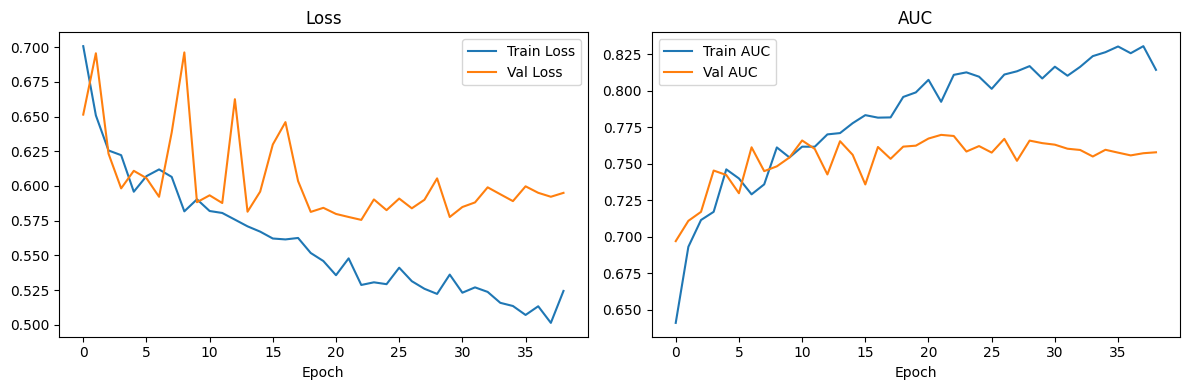


Final Training Metrics:
  accuracy            : 0.7318
  auc                 : 0.8144
  loss                : 0.5244
  precision           : 0.7282
  sensitivity         : 0.7396
  learning_rate       : 0.0001

Final Validation Metrics:
  val_accuracy        : 0.6646
  val_auc             : 0.7579
  val_loss            : 0.5950
  val_precision       : 0.6549
  val_sensitivity     : 0.6958

✓ Model saved ke: /content/.echonext_cache/final_model_echonext_hfpef_hfref.keras
✓ Berhasil membuat arsip ZIP: /content/.echonext_cache/echonext_model_bundle.zip

 Mengunduh file zip ke komputer lokal...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

DONE! Model siap untuk cascade inference.


In [49]:
# ============================================================
# CELL 11: Visualisasi & Save Model + Export ZIP
# ============================================================
import json
import zipfile
import matplotlib.pyplot as plt

print("=" * 60)
print("HASIL & SAVE MODEL")
print("=" * 60)

# --- 1. Visualisasi Training History ---
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history.history["loss"], label="Train Loss")
axes[0].plot(history.history["val_loss"], label="Val Loss")
axes[0].set_title("Loss")
axes[0].set_xlabel("Epoch")
axes[0].legend()

if "auc" in history.history:
    axes[1].plot(history.history["auc"], label="Train AUC")
    axes[1].plot(history.history["val_auc"], label="Val AUC")
    axes[1].set_title("AUC")
    axes[1].set_xlabel("Epoch")
    axes[1].legend()

plt.tight_layout()
plt.show()

print("\nFinal Training Metrics:")
for metric, value in history.history.items():
    if not metric.startswith("val_"):
        print(f"  {metric:20s}: {value[-1]:.4f}")

print("\nFinal Validation Metrics:")
for metric, value in history.history.items():
    if metric.startswith("val_"):
        print(f"  {metric:20s}: {value[-1]:.4f}")

# --- 2. Menyimpan File Model & JSON ---
final_model_path = CONFIG["cache_dir"] / "final_model_echonext_hfpef_hfref.keras"
weights_path = CONFIG["cache_dir"] / "class_weights_echonext.json"
config_path = CONFIG["cache_dir"] / "config_echonext.json"

# Simpan Keras Model
model.save(final_model_path)
print(f"\n✓ Model saved ke: {final_model_path}")

# Simpan Class Weights
with open(weights_path, "w") as f:
    json.dump(class_weights_dict, f)

# Simpan Config
with open(config_path, "w") as f:
    json.dump({
        "selected_leads": CONFIG["selected_leads"],
        "input_shape": CONFIG["input_shape"],
        "lvef_threshold_hfref": CONFIG["lvef_threshold_hfref"],
        "lvef_threshold_hfpef": CONFIG["lvef_threshold_hfpef"],
    }, f)

# --- 3. Mengompresi File ke dalam ZIP ---
zip_filename = CONFIG["cache_dir"] / "echonext_model_bundle.zip"
files_to_zip = [final_model_path, weights_path, config_path]

with zipfile.ZipFile(zip_filename, "w", zipfile.ZIP_DEFLATED) as zipf:
    for file_path in files_to_zip:
        # arcname=file_path.name memastikan file tidak disimpan dengan full folder path di dalam zip
        zipf.write(file_path, arcname=file_path.name)

print(f"✓ Berhasil membuat arsip ZIP: {zip_filename}")

# --- 4. Mengunduh File ZIP (Google Colab / Environment Check) ---
try:
    from google.colab import files
    print("\n Mengunduh file zip ke komputer lokal...")
    files.download(str(zip_filename))
except ImportError:
    print(f"\nℹ Anda berada di luar Google Colab. File zip tersimpan di: {zip_filename}")

print("=" * 60)
print("DONE! Model siap untuk cascade inference.")
print("=" * 60)

EVALUATION: CONFUSION MATRIX + BEST THRESHOLD
30/30 ━━━━━━━━━━━━━━━━━━━━ 16s 441ms/step

Classification Report - Threshold 0.5:
              precision    recall  f1-score   support

       HFrEF       0.71      0.65      0.68       240
       HFpEF       0.68      0.74      0.71       240

    accuracy                           0.70       480
   macro avg       0.70      0.70      0.70       480
weighted avg       0.70      0.70      0.70       480

Best threshold (Youden): 0.5470

Classification Report - Best Threshold:
              precision    recall  f1-score   support

       HFrEF       0.70      0.72      0.71       240
       HFpEF       0.71      0.70      0.71       240

    accuracy                           0.71       480
   macro avg       0.71      0.71      0.71       480
weighted avg       0.71      0.71      0.71       480



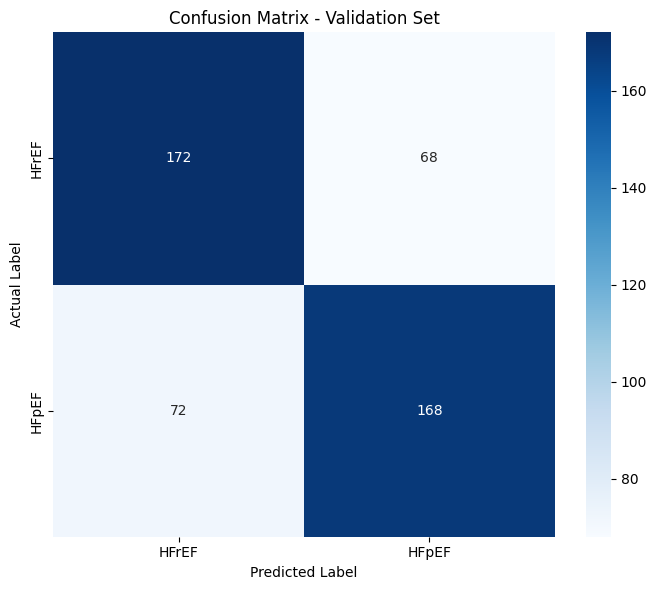

In [50]:
# ============================================================
# CELL 12: Evaluation + Confusion Matrix (UPDATED)
# ============================================================
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_curve
)
import seaborn as sns

print("=" * 60)
print("EVALUATION: CONFUSION MATRIX + BEST THRESHOLD")
print("=" * 60)

y_pred_probs = model.predict(val_ds, verbose=1).flatten()

# ============================================================
# Default threshold 0.5
# ============================================================
y_pred_05 = (y_pred_probs >= 0.5).astype(int)

print("\nClassification Report - Threshold 0.5:")
print(classification_report(
    y_val,
    y_pred_05,
    target_names=["HFrEF", "HFpEF"]
))

# ============================================================
# Best threshold dengan Youden index
# ============================================================
fpr, tpr, thresholds = roc_curve(y_val, y_pred_probs)

youden_scores = tpr - fpr

# Ambil threshold yang valid antara 0 dan 1
valid_mask = (thresholds >= 0) & (thresholds <= 1)

if valid_mask.any():
    valid_thresholds = thresholds[valid_mask]
    valid_youden = youden_scores[valid_mask]
    best_thr = valid_thresholds[np.argmax(valid_youden)]
else:
    best_thr = 0.5

y_pred_best = (y_pred_probs >= best_thr).astype(int)

print(f"Best threshold (Youden): {best_thr:.4f}")
print("\nClassification Report - Best Threshold:")
print(classification_report(
    y_val,
    y_pred_best,
    target_names=["HFrEF", "HFpEF"]
))

# ============================================================
# Confusion matrix
# ============================================================
cm = confusion_matrix(y_val, y_pred_best)

plt.figure(figsize=(7, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["HFrEF", "HFpEF"],
    yticklabels=["HFrEF", "HFpEF"]
)

plt.title("Confusion Matrix - Validation Set")
plt.ylabel("Actual Label")
plt.xlabel("Predicted Label")
plt.tight_layout()
plt.show()

print("=" * 60)